In [1]:
import pandas as pd

# Load the dataset
file_path = 'dataset_wellnessdimensions.csv'
data = pd.read_csv(file_path)

# Display the first few rows of the dataset to understand its structure
data.head()

,Unnamed: 0,Text,Aspect,Explanations
0,0,Once it happens there is no going back and you...,4,empty void of darkness
1,1,Now i am filled with guilt and stuck feeling l...,4,filled with guilt and stuck feeling like crap
2,2,And i got home and the voices returned and kep...,4,piece of shit
3,3,"Before her I survived since shit, sexual assau...",1,sexual assaults
4,4,I feel like there are only three things that y...,1,"ugly, dumb, and useless"


In [2]:
print(data.describe())

        Unnamed: 0       Aspect
count  3092.000000  3092.000000
mean   1545.500000     2.530724
std     892.727842     1.062901
min       0.000000     1.000000
25%     772.750000     2.000000
50%    1545.500000     3.000000
75%    2318.250000     3.000000
max    3091.000000     4.000000


In [3]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3092 entries, 0 to 3091
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    3092 non-null   int64 
 1   Text          3092 non-null   object
 2   Aspect        3092 non-null   int64 
 3   Explanations  3092 non-null   object
dtypes: int64(2), object(2)
memory usage: 96.8+ KB
None


In [4]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [5]:
# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/vedantagarwal/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/vedantagarwal/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/vedantagarwal/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [6]:
# Initialize Lemmatizer
lemmatizer = WordNetLemmatizer()

# Define stop words and punctuation set
stop_words = set(stopwords.words('english'))
punctuation = set(string.punctuation)

In [7]:
# Function to clean and preprocess text
def preprocess_text(text):
    # Lowercase the text
    text = text.lower()
    # Tokenize the text
    tokens = word_tokenize(text)
    # Remove stopwords and punctuation, and lemmatize the words
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and word not in punctuation]
    # Join tokens back into a string
    return ' '.join(cleaned_tokens)

# Apply the preprocessing to the 'Text' and 'Explanations' columns
data['Cleaned_Text'] = data['Text'].apply(preprocess_text)
data['Cleaned_Explanations'] = data['Explanations'].apply(preprocess_text)

# Drop unnecessary columns
cleaned_data = data[['Cleaned_Text', 'Cleaned_Explanations', 'Aspect']]

# Show the cleaned dataset
cleaned_data.head()

,Cleaned_Text,Cleaned_Explanations,Aspect
0,happens going back stuck empty void darkness f...,empty void darkness,4
1,filled guilt stuck feeling like crap,filled guilt stuck feeling like crap,4
2,got home voice returned kept telling piece shit,piece shit,4
3,survived since shit sexual assault like,sexual assault,1
4,feel like three thing absolutely dumb ugly use...,ugly dumb useless,1


In [8]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

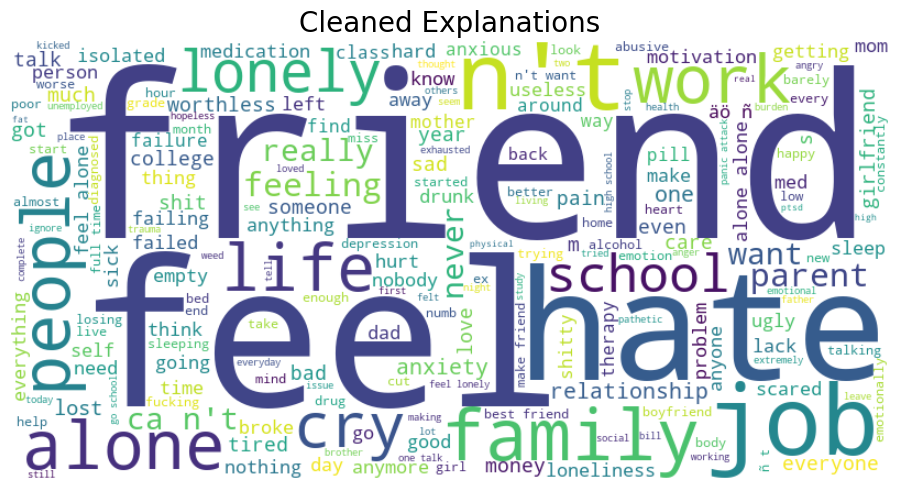

In [9]:
# Combine all the cleaned explanations into one large string
explanations_text = ' '.join(cleaned_data['Cleaned_Explanations'].astype(str))

# Generate a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=200).generate(explanations_text)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # No axis for a cleaner visualization
plt.title("Cleaned Explanations", fontsize=20)
plt.tight_layout()
plt.show()

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Feature Engineering using TF-IDF for 'Cleaned_Text'
tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')

# Apply TF-IDF to Cleaned_Text and Cleaned_Explanations
tfidf_text = tfidf_vectorizer.fit_transform(cleaned_data['Cleaned_Text'])
tfidf_explanations = tfidf_vectorizer.fit_transform(cleaned_data['Cleaned_Explanations'])

# Extract the feature names for word cloud creation
feature_names_text = tfidf_vectorizer.get_feature_names_out()
feature_names_explanations = tfidf_vectorizer.get_feature_names_out()

# Combine all feature names into a single string for word cloud visualization
tfidf_text_combined = ' '.join(feature_names_text)
tfidf_explanations_combined = ' '.join(feature_names_explanations)

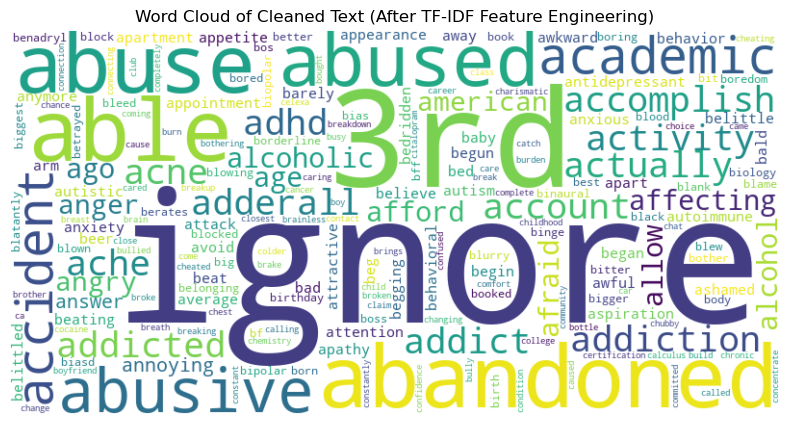

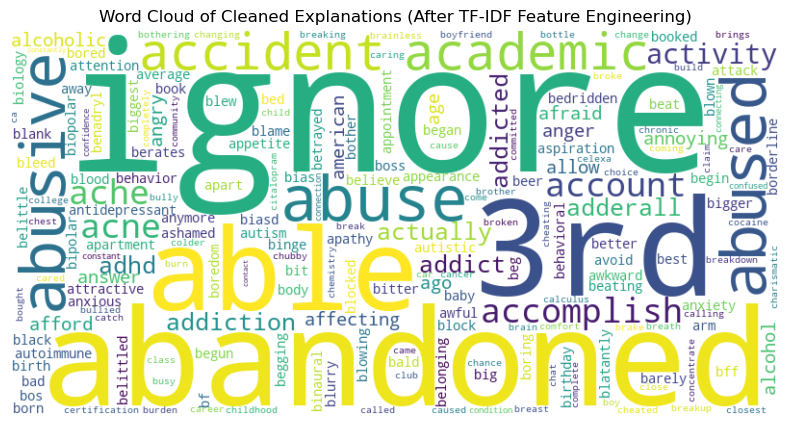

In [11]:
# Generate word clouds for both 'Cleaned_Text' and 'Cleaned_Explanations'
wordcloud_text = WordCloud(width=800, height=400, background_color='white').generate(tfidf_text_combined)
wordcloud_explanations = WordCloud(width=800, height=400, background_color='white').generate(tfidf_explanations_combined)

# Plot the word cloud for 'Cleaned_Text'
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_text, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Text (After TF-IDF Feature Engineering)')
plt.show()

# Plot the word cloud for 'Cleaned_Explanations'
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_explanations, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Explanations (After TF-IDF Feature Engineering)')
plt.show()


In [12]:
from tensorflow.keras import layers, models

In [13]:
import numpy as np

# Combine tfidf_text and tfidf_explanations
X_tfidf = np.hstack([tfidf_text.toarray(), tfidf_explanations.toarray()])

In [14]:
# Define the dimensions of the input
input_dim = X_tfidf.shape[1]

# Input Layer
inputs = layers.Input(shape=(input_dim,))

In [15]:


# Encoder Layers
encoded = layers.Dense(512, activation='relu')(inputs)
encoded = layers.Dense(256, activation='relu')(encoded)

In [16]:
# Attention Mechanism
attention_probs = layers.Dense(256, activation='softmax')(encoded)
attention_output = layers.multiply([encoded, attention_probs])

In [17]:
# Decoder Layers
decoded = layers.Dense(512, activation='relu')(attention_output)
decoded = layers.Dense(input_dim, activation='sigmoid')(decoded)

In [18]:
# Build Autoencoder Model
autoencoder = models.Model(inputs, decoded)

In [19]:
# Compile the model
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

# Display the model structure
autoencoder.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 2000)]               0         []                            
                                                                                                  
 dense (Dense)               (None, 512)                  1024512   ['input_1[0][0]']             
                                                                                                  
 dense_1 (Dense)             (None, 256)                  131328    ['dense[0][0]']               
                                                                                                  
 dense_2 (Dense)             (None, 256)                  65792     ['dense_1[0][0]']             
                                                                                              

In [20]:
# Train the autoencoder
history = autoencoder.fit(X_tfidf, X_tfidf, epochs=50, batch_size=64, validation_split=0.2)

Epoch 1/50
39/39 [==============================] - 1s 12ms/step - loss: 0.2273 - val_loss: 0.1699
Epoch 2/50
39/39 [==============================] - 0s 13ms/step - loss: 0.0568 - val_loss: 9.6103e-04
Epoch 3/50
39/39 [==============================] - 2s 46ms/step - loss: 9.6616e-04 - val_loss: 9.4827e-04
Epoch 4/50
39/39 [==============================] - 4s 103ms/step - loss: 9.6582e-04 - val_loss: 9.4820e-04
Epoch 5/50
39/39 [==============================] - 2s 49ms/step - loss: 9.6582e-04 - val_loss: 9.4819e-04
Epoch 6/50
39/39 [==============================] - 2s 42ms/step - loss: 9.6581e-04 - val_loss: 9.4819e-04
Epoch 7/50
39/39 [==============================] - 2s 40ms/step - loss: 9.6580e-04 - val_loss: 9.4818e-04
Epoch 8/50
39/39 [==============================] - 1s 32ms/step - loss: 9.6579e-04 - val_loss: 9.4817e-04
Epoch 9/50
39/39 [==============================] - 1s 30ms/step - loss: 9.6578e-04 - val_loss: 9.4816e-04
Epoch 10/50
39/39 [=============================

In [21]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Predict the reconstructed data
reconstructed_data = autoencoder.predict(X_tfidf)

# Calculate the Mean Squared Error (MSE) for each sample
reconstruction_error = np.mean(np.square(X_tfidf - reconstructed_data), axis=1)

# Display the first few reconstruction errors
print("Reconstruction Error for the first 10 samples:")
print(reconstruction_error[:10])

# Calculate the overall mean reconstruction error
mean_reconstruction_error = np.mean(reconstruction_error)
print(f"Overall Mean Reconstruction Error: {mean_reconstruction_error}")


97/97 [==============================] - 2s 19ms/step
Reconstruction Error for the first 10 samples:
[0.00099635 0.00099754 0.00099733 0.000998   0.00099797 0.00099783
 0.0009992  0.00099753 0.00099807 0.0009984 ]
Overall Mean Reconstruction Error: 0.0009617562983939053


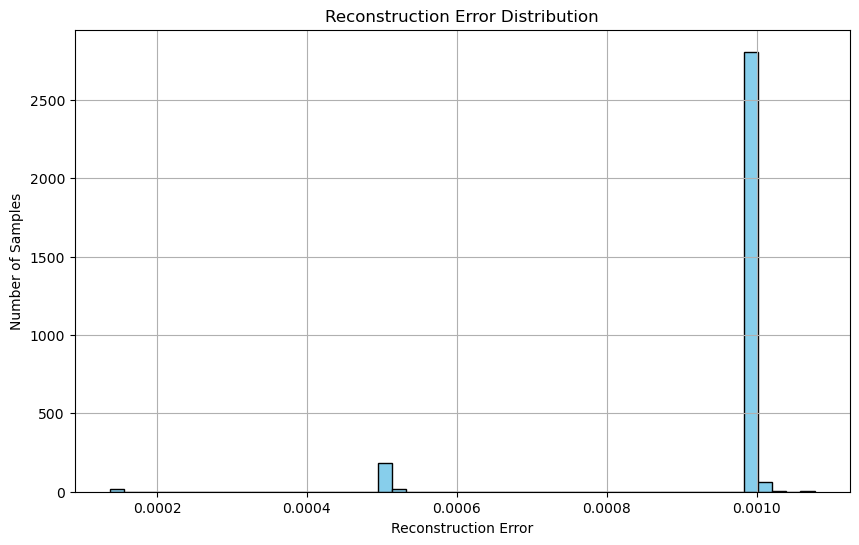

In [22]:
import matplotlib.pyplot as plt

# Plot the reconstruction error distribution
plt.figure(figsize=(10, 6))
plt.hist(reconstruction_error, bins=50, color='skyblue', edgecolor='black')
plt.title('Reconstruction Error Distribution')
plt.xlabel('Reconstruction Error')
plt.ylabel('Number of Samples')
plt.grid(True)
plt.show()

20/20 [==============================] - 0s 2ms/step
Validation Mean Reconstruction Error: 0.0009595327222474404


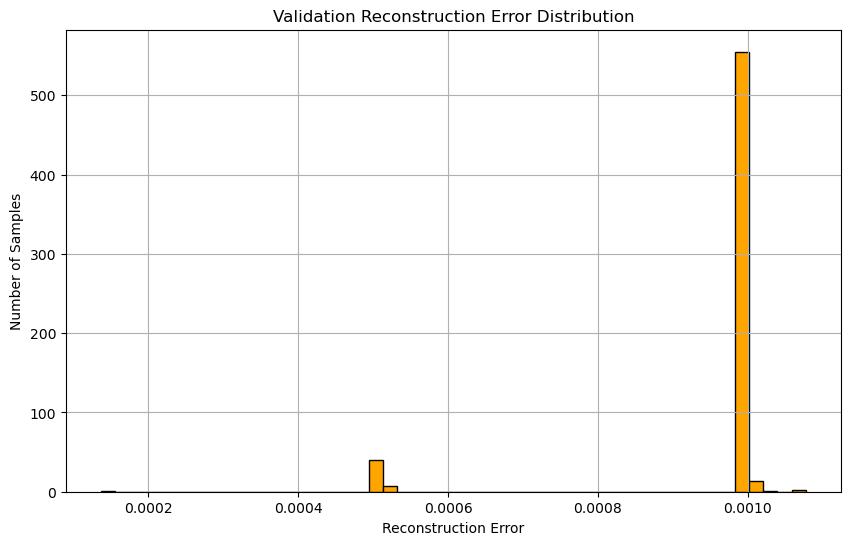

In [23]:
# Step 1: Split the data into training and validation sets
from sklearn.model_selection import train_test_split
X_train, X_val = train_test_split(X_tfidf, test_size=0.2, random_state=42)

# Step 2: Train the autoencoder on X_train and evaluate on X_val
# Assuming your autoencoder has already been trained...

# Step 3: Predict the reconstructed data for the validation set
X_val_reconstructed = autoencoder.predict(X_val)

# Step 4: Calculate the reconstruction error for the validation set
validation_reconstruction_error = np.mean(np.square(X_val - X_val_reconstructed), axis=1)

# Step 5: Calculate the overall mean reconstruction error for the validation set
mean_val_reconstruction_error = np.mean(validation_reconstruction_error)
print(f"Validation Mean Reconstruction Error: {mean_val_reconstruction_error}")

# Step 6: Plot the validation reconstruction error distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(validation_reconstruction_error, bins=50, color='orange', edgecolor='black')
plt.title('Validation Reconstruction Error Distribution')
plt.xlabel('Reconstruction Error')
plt.ylabel('Number of Samples')
plt.grid(True)
plt.show()


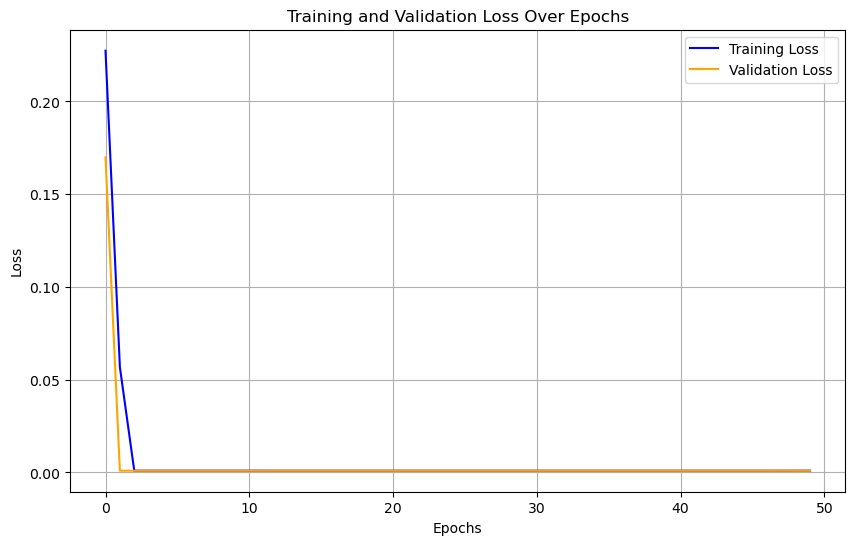

In [24]:
import matplotlib.pyplot as plt

# Assuming the model has been trained and the 'history' object is available

# Retrieve the loss values from the history object
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [25]:
from sklearn.metrics import mean_absolute_error

# Calculate the Mean Absolute Error for each sample
mae_reconstruction_error = np.mean(np.abs(X_tfidf - reconstructed_data), axis=1)

# Display the first few MAE values
print("Mean Absolute Error for the first 10 samples:")
print(mae_reconstruction_error[:10])

# Calculate the overall mean absolute error
mean_mae_reconstruction_error = np.mean(mae_reconstruction_error)
print(f"Overall Mean Absolute Error: {mean_mae_reconstruction_error}")


Mean Absolute Error for the first 10 samples:
[0.00343802 0.00276001 0.00261807 0.00231178 0.00249585 0.00248353
 0.00304985 0.00287465 0.00274568 0.00239641]
Overall Mean Absolute Error: 0.0027746354541523174


In [26]:
# Visualizing the original and reconstructed data for a few samples
num_samples = 5
for i in range(num_samples):
    print(f"Sample {i + 1}:")
    print("Original:", X_tfidf[i][:10])   # Print the first 10 features of the original input
    print("Reconstructed:", reconstructed_data[i][:10])  # Print the first 10 features of the reconstructed input
    print("\n")

Sample 1:
Original: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Reconstructed: [0.00142574 0.00170524 0.00170247 0.00199383 0.0015435  0.00126994
 0.00133977 0.00184511 0.00188879 0.00151143]


Sample 2:
Original: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Reconstructed: [0.00047792 0.00059005 0.00058486 0.00070599 0.00052201 0.0004155
 0.0004443  0.00064614 0.00066747 0.00051411]


Sample 3:
Original: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Reconstructed: [0.0004856  0.00059925 0.00059404 0.00071675 0.00053029 0.00042231
 0.00045149 0.00065611 0.00067769 0.00052226]


Sample 4:
Original: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Reconstructed: [0.00090028 0.0010912  0.00108616 0.00128834 0.00097805 0.00079364
 0.00084204 0.00118673 0.00121957 0.00096029]


Sample 5:
Original: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Reconstructed: [0.0002782  0.00034893 0.00034461 0.00042224 0.00030529 0.00023903
 0.00025731 0.00038434 0.00039878 0.00030143]




In [27]:
import numpy as np
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers.legacy import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

In [28]:
X_train, X_val = train_test_split(X_tfidf, test_size=0.2, random_state=42)

In [29]:

# Step 2: Define the fitness function (Validation loss)
def fitness_function(params):
    learning_rate = params[0]
    num_neurons = int(params[1])
    batch_size = int(params[2])

    # Build the autoencoder model with the given hyperparameters
    inputs = layers.Input(shape=(X_train.shape[1],))

    # Encoder with dynamic number of neurons
    encoded = layers.Dense(num_neurons, activation='relu')(inputs)
    encoded = layers.Dense(256, activation='relu')(encoded)

    # Attention mechanism
    attention_probs = layers.Dense(256, activation='softmax')(encoded)
    attention_output = layers.multiply([encoded, attention_probs])

    # Decoder
    decoded = layers.Dense(num_neurons, activation='relu')(attention_output)
    decoded = layers.Dense(X_train.shape[1], activation='sigmoid')(decoded)

    # Compile the autoencoder
    autoencoder = models.Model(inputs, decoded)
    autoencoder.compile(optimizer=Adam(learning_rate=learning_rate), loss='mean_squared_error')

    # Early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)

    # Train the model (Silent training for optimization purposes)
    history = autoencoder.fit(X_train, X_train,
                              epochs=50,
                              batch_size=batch_size,
                              validation_data=(X_val, X_val),
                              callbacks=[early_stopping],
                              verbose=0)

    # Return the final validation loss as the fitness score
    val_loss = history.history['val_loss'][-1]
    return val_loss

In [30]:

# Step 3: SMO setup (Define the parameter ranges)
param_ranges = {
    "learning_rate": [0.0001, 0.01],   # Learning rate range
    "num_neurons": [128, 512],         # Number of neurons range
    "batch_size": [16, 128]            # Batch size range
}

In [31]:
# Number of spider monkeys (population size) and iterations
num_spiders = 10
iterations = 20

In [32]:
# Initialize population randomly
populations = np.array([
    [
        np.random.uniform(param_ranges["learning_rate"][0], param_ranges["learning_rate"][1]),
        np.random.uniform(param_ranges["num_neurons"][0], param_ranges["num_neurons"][1]),
        np.random.uniform(param_ranges["batch_size"][0], param_ranges["batch_size"][1])
    ]
    for _ in range(num_spiders)
])


In [33]:
# Step 4: SMO Algorithm for hyperparameter optimization
for iteration in range(iterations):
    # Evaluate the fitness of each spider monkey
    fitness_scores = np.array([fitness_function(params) for params in populations])

    # Find the best (global leader) spider monkey based on fitness score (lowest loss)
    global_leader_idx = np.argmin(fitness_scores)
    global_leader = populations[global_leader_idx]

    # Print current best loss for monitoring
    print(f"Iteration {iteration+1}: Best Validation Loss = {fitness_scores[global_leader_idx]}")

    # Update the population (Each spider monkey adjusts its position)
    for i in range(num_spiders):
        if i != global_leader_idx:
            populations[i] = populations[i] + np.random.uniform(-0.01, 0.01, populations[i].shape) * (global_leader - populations[i])

    # Ensure updated values stay within the defined parameter ranges
    populations[:, 0] = np.clip(populations[:, 0], param_ranges["learning_rate"][0], param_ranges["learning_rate"][1])
    populations[:, 1] = np.clip(populations[:, 1], param_ranges["num_neurons"][0], param_ranges["num_neurons"][1])
    populations[:, 2] = np.clip(populations[:, 2], param_ranges["batch_size"][0], param_ranges["batch_size"][1])

Iteration 1: Best Validation Loss = 0.0009541274630464613
Iteration 2: Best Validation Loss = 0.0009084907360374928
Iteration 3: Best Validation Loss = 0.0009589663241058588
Iteration 4: Best Validation Loss = 0.0009352616616524756
Iteration 5: Best Validation Loss = 0.0009572072885930538
Iteration 6: Best Validation Loss = 0.0009011277579702437
Iteration 7: Best Validation Loss = 0.0009599928162060678
Iteration 8: Best Validation Loss = 0.0008988838526420295
Iteration 9: Best Validation Loss = 0.0009588234242983162
Iteration 10: Best Validation Loss = 0.0009590129484422505
Iteration 11: Best Validation Loss = 0.0009591998532414436
Iteration 12: Best Validation Loss = 0.0009139018366113305
Iteration 13: Best Validation Loss = 0.0009590439149178565
Iteration 14: Best Validation Loss = 0.0009092740365304053
Iteration 15: Best Validation Loss = 0.0009027475025504827
Iteration 16: Best Validation Loss = 0.0009588795364834368
Iteration 17: Best Validation Loss = 0.0009579521720297635
Iterat

In [34]:
# Step 5: Output the best hyperparameters found by SMO
best_hyperparams = global_leader
print(f"Best Hyperparameters Found: Learning Rate = {best_hyperparams[0]}, Num Neurons = {int(best_hyperparams[1])}, Batch Size = {int(best_hyperparams[2])}")

Best Hyperparameters Found: Learning Rate = 0.0018008855601954205, Num Neurons = 270, Batch Size = 31


Epoch 1/100
80/80 [==============================] - 1s 10ms/step - loss: 1.3541 - val_loss: 0.0200 - lr: 0.0020
Epoch 2/100
80/80 [==============================] - 1s 7ms/step - loss: 0.0037 - val_loss: 0.0072 - lr: 0.0020
Epoch 3/100
80/80 [==============================] - 1s 8ms/step - loss: 0.0018 - val_loss: 0.0039 - lr: 0.0020
Epoch 4/100
80/80 [==============================] - 0s 6ms/step - loss: 0.0019 - val_loss: 0.0025 - lr: 0.0020
Epoch 5/100
80/80 [==============================] - 0s 6ms/step - loss: 0.0016 - val_loss: 0.0018 - lr: 0.0020
Epoch 6/100
80/80 [==============================] - 0s 6ms/step - loss: 0.0014 - val_loss: 0.0038 - lr: 0.0020
Epoch 7/100
80/80 [==============================] - 1s 6ms/step - loss: 0.0027 - val_loss: 0.0016 - lr: 0.0020
Epoch 8/100
80/80 [==============================] - 0s 6ms/step - loss: 0.0016 - val_loss: 0.0015 - lr: 0.0020
Epoch 9/100
80/80 [==============================] - 0s 6ms/step - loss: 0.0011 - val_loss: 0.0010 - lr

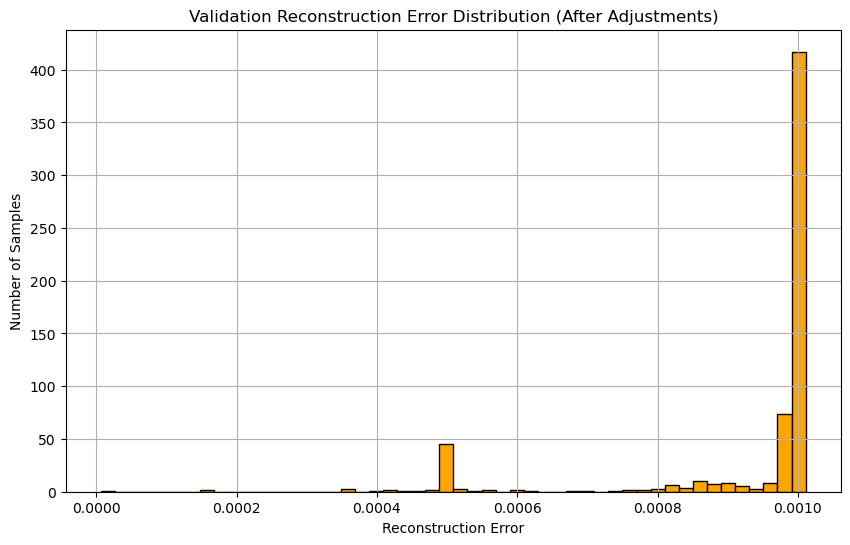

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import legacy  # Use legacy optimizer for better performance
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Step 1: Split the data into training and validation sets
X_train, X_val = train_test_split(X_tfidf, test_size=0.2, random_state=42)

# Assuming best_hyperparams is defined as [learning_rate, num_neurons, batch_size]
# Example: best_hyperparams = [0.0005, 512, 32]

# Step 2: Build the autoencoder model with modified architecture
final_autoencoder = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(int(best_hyperparams[1] * 2), kernel_regularizer='l2'),  # Increase neurons
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.3),  # Adjust dropout rate
    
    layers.Dense(int(best_hyperparams[1]), kernel_regularizer='l2'),  # Keep high
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    
    layers.Dense(int(best_hyperparams[1] / 2)),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    
    layers.Dense(int(best_hyperparams[1] / 2), activation='relu'),
    layers.Dense(X_train.shape[1], activation='sigmoid')  # Match input shape
])

# Step 3: Compile the model with the optimized learning rate
final_optimizer = legacy.Adam(learning_rate=0.002)  # Experiment with a smaller learning rate
final_autoencoder.compile(optimizer=final_optimizer, loss='mean_squared_error')

# Step 4: Set up early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Step 5: Train the model with the best hyperparameters
history = final_autoencoder.fit(X_train, X_train, 
                                epochs=100,  # Increased epochs for better convergence
                                batch_size=int(best_hyperparams[2]),  # Use optimized batch size
                                validation_data=(X_val, X_val), 
                                callbacks=[early_stopping, reduce_lr], 
                                verbose=1)

# Step 6: Calculate reconstruction errors
X_val_reconstructed = final_autoencoder.predict(X_val)

# Step 7: Calculate Mean Absolute Error
mae_val = mean_absolute_error(X_val, X_val_reconstructed)
mae_train = mean_absolute_error(X_train, final_autoencoder.predict(X_train))

# Step 8: Display the MAE results
print(f"Mean Absolute Error on Training Set: {mae_train}")
print(f"Mean Absolute Error on Validation Set: {mae_val}")

# Step 9: Calculate and display Mean Reconstruction Error
validation_reconstruction_error = np.mean(np.square(X_val - X_val_reconstructed), axis=1)
mean_val_reconstruction_error = np.mean(validation_reconstruction_error)
print(f"Validation Mean Reconstruction Error: {mean_val_reconstruction_error}")

# Step 10: Plot validation reconstruction error distribution
plt.figure(figsize=(10, 6))
plt.hist(validation_reconstruction_error, bins=50, color='orange', edgecolor='black')
plt.title('Validation Reconstruction Error Distribution (After Adjustments)')
plt.xlabel('Reconstruction Error')
plt.ylabel('Number of Samples')
plt.grid(True)
plt.show()


20/20 [==============================] - 0s 5ms/step
Original Validation Mean Reconstruction Error: 0.0009595327222474404
Original Mean Absolute Error: 0.002775891521726044
20/20 [==============================] - 0s 2ms/step
Optimized Validation Mean Reconstruction Error: 0.0009281895011772291
Optimized Mean Absolute Error: 0.002784453354636607
                      Metric  Before SMO  After SMO
0  Mean Reconstruction Error    0.000960   0.000928
1        Mean Absolute Error    0.002776   0.002784


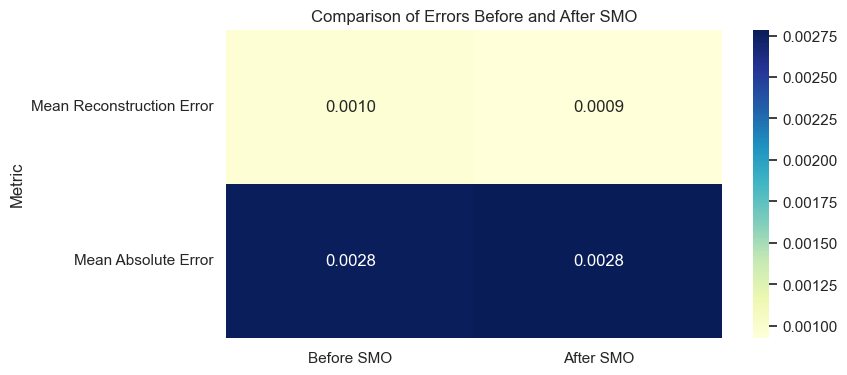

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Step 1: Split the data into training and validation sets
X_train, X_val = train_test_split(X_tfidf, test_size=0.2, random_state=42)

# Step 2: Original autoencoder predictions
X_val_reconstructed_original = autoencoder.predict(X_val)

# Step 3: Calculate reconstruction error for original model
validation_reconstruction_error_original = np.mean(np.square(X_val - X_val_reconstructed_original), axis=1)
mean_val_reconstruction_error_original = np.mean(validation_reconstruction_error_original)

# Step 4: Calculate MAE for original model using X_val
mae_reconstruction_error_original = np.mean(np.abs(X_val - X_val_reconstructed_original), axis=1)
mean_mae_reconstruction_error_original = np.mean(mae_reconstruction_error_original)

# Print original errors
print(f"Original Validation Mean Reconstruction Error: {mean_val_reconstruction_error_original}")
print(f"Original Mean Absolute Error: {mean_mae_reconstruction_error_original}")

# Step 5: Optimized autoencoder predictions (after SMO)
X_val_reconstructed_optimized = final_autoencoder.predict(X_val)

# Step 6: Calculate reconstruction error for optimized model
validation_reconstruction_error_optimized = np.mean(np.square(X_val - X_val_reconstructed_optimized), axis=1)
mean_val_reconstruction_error_optimized = np.mean(validation_reconstruction_error_optimized)

# Step 7: Calculate MAE for optimized model using X_val
mae_reconstruction_error_optimized = np.mean(np.abs(X_val - X_val_reconstructed_optimized), axis=1)
mean_mae_reconstruction_error_optimized = np.mean(mae_reconstruction_error_optimized)

# Print optimized errors
print(f"Optimized Validation Mean Reconstruction Error: {mean_val_reconstruction_error_optimized}")
print(f"Optimized Mean Absolute Error: {mean_mae_reconstruction_error_optimized}")

# Step 8: Create a DataFrame for comparison
comparison_data = {
    'Metric': ['Mean Reconstruction Error', 'Mean Absolute Error'],
    'Before SMO': [mean_val_reconstruction_error_original, mean_mae_reconstruction_error_original],
    'After SMO': [mean_val_reconstruction_error_optimized, mean_mae_reconstruction_error_optimized]
}

comparison_df = pd.DataFrame(comparison_data)

# Step 9: Print the comparison table
print(comparison_df)

# Optional: Display a pretty table
import seaborn as sns
sns.set(style="whitegrid")
plt.figure(figsize=(8, 4))
sns.heatmap(comparison_df.set_index('Metric'), annot=True, cmap='YlGnBu', fmt='.4f')
plt.title('Comparison of Errors Before and After SMO')
plt.show()


20/20 [==============================] - 0s 4ms/step
Original Validation Mean Reconstruction Error: 0.000960
Original Mean Absolute Error: 0.002776
20/20 [==============================] - 0s 2ms/step
Optimized Validation Mean Reconstruction Error: 0.000928
Optimized Mean Absolute Error: 0.002784
                      Metric  Before SMO  After SMO
0  Mean Reconstruction Error    0.000960   0.000928
1        Mean Absolute Error    0.002776   0.002784


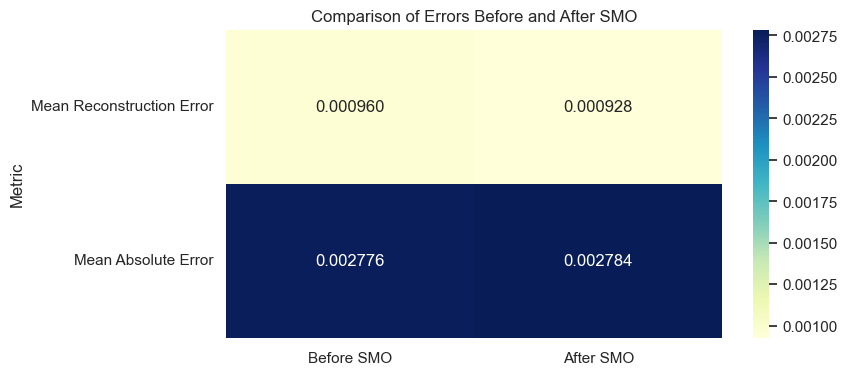

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Step 1: Split the data into training and validation sets
X_train, X_val = train_test_split(X_tfidf, test_size=0.2, random_state=42)

# Step 2: Original autoencoder predictions
X_val_reconstructed_original = autoencoder.predict(X_val)

# Step 3: Calculate reconstruction error for original model
validation_reconstruction_error_original = np.mean(np.square(X_val - X_val_reconstructed_original), axis=1)
mean_val_reconstruction_error_original = np.mean(validation_reconstruction_error_original)

# Step 4: Calculate MAE for original model using X_val
mae_reconstruction_error_original = np.mean(np.abs(X_val - X_val_reconstructed_original), axis=1)
mean_mae_reconstruction_error_original = np.mean(mae_reconstruction_error_original)

# Print original errors
print(f"Original Validation Mean Reconstruction Error: {mean_val_reconstruction_error_original:.6f}")
print(f"Original Mean Absolute Error: {mean_mae_reconstruction_error_original:.6f}")

# Step 5: Optimized autoencoder predictions (after SMO)
X_val_reconstructed_optimized = final_autoencoder.predict(X_val)

# Step 6: Calculate reconstruction error for optimized model
validation_reconstruction_error_optimized = np.mean(np.square(X_val - X_val_reconstructed_optimized), axis=1)
mean_val_reconstruction_error_optimized = np.mean(validation_reconstruction_error_optimized)

# Step 7: Calculate MAE for optimized model using X_val
mae_reconstruction_error_optimized = np.mean(np.abs(X_val - X_val_reconstructed_optimized), axis=1)
mean_mae_reconstruction_error_optimized = np.mean(mae_reconstruction_error_optimized)

# Print optimized errors
print(f"Optimized Validation Mean Reconstruction Error: {mean_val_reconstruction_error_optimized:.6f}")
print(f"Optimized Mean Absolute Error: {mean_mae_reconstruction_error_optimized:.6f}")

# Step 8: Create a DataFrame for comparison
comparison_data = {
    'Metric': ['Mean Reconstruction Error', 'Mean Absolute Error'],
    'Before SMO': [mean_val_reconstruction_error_original, mean_mae_reconstruction_error_original],
    'After SMO': [mean_val_reconstruction_error_optimized, mean_mae_reconstruction_error_optimized]
}

comparison_df = pd.DataFrame(comparison_data)x

# Round values to six decimal places for display
comparison_df['Before SMO'] = comparison_df['Before SMO'].round(6)
comparison_df['After SMO'] = comparison_df['After SMO'].round(6)

# Step 9: Print the comparison table
print(comparison_df)

# Optional: Display a pretty table
import seaborn as sns
sns.set(style="whitegrid")
plt.figure(figsize=(8, 4))
sns.heatmap(comparison_df.set_index('Metric'), annot=True, cmap='YlGnBu', fmt='.6f')
plt.title('Comparison of Errors Before and After SMO')
plt.show()


Number of anomalies detected: 1
Results saved to 'autoencoder_results_with_anomalies.csv'


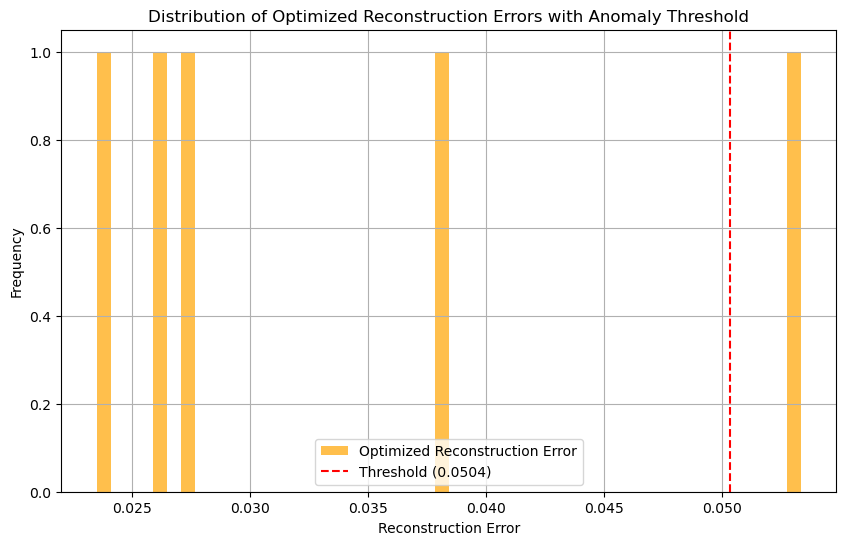

In [27]:
# Continuing from Cell 36 of the PDF
# Assuming cleaned_data, X_tfidf, autoencoder, final_autoencoder, reconstruction_error_original,
# reconstruction_error_optimized, mae_reconstruction_error_original, and mae_reconstruction_error_optimized
# are available from previous cells

# Step 1: Anomaly Detection using Optimized Reconstruction Errors
threshold = np.percentile(reconstruction_error_optimized, 95)  # Top 5% as anomalies
anomalies = reconstruction_error_optimized > threshold
print(f"Number of anomalies detected: {np.sum(anomalies)}")

# Step 2: Add results to cleaned_data
cleaned_data = cleaned_data.assign(
    Original_Reconstruction_Error=reconstruction_error_original,
    Optimized_Reconstruction_Error=reconstruction_error_optimized,
    Original_MAE=mae_reconstruction_error_original,
    Optimized_MAE=mae_reconstruction_error_optimized,
    Is_Anomaly=anomalies
)

# Step 3: Save the results to a CSV file
cleaned_data.to_csv('autoencoder_results_with_anomalies.csv', index=False)
print("Results saved to 'autoencoder_results_with_anomalies.csv'")

# Step 4: Visualize the Reconstruction Error Distribution with Anomaly Threshold
plt.figure(figsize=(10, 6))
plt.hist(reconstruction_error_optimized, bins=50, alpha=0.7, color='orange', label='Optimized Reconstruction Error')
plt.axvline(threshold, color='r', linestyle='--', label=f'Threshold ({threshold:.4f})')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.title('Distribution of Optimized Reconstruction Errors with Anomaly Threshold')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
import nltk
import pandas as pd
import numpy as np
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

# Download required NLTK data (run once)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
punctuation = set(string.punctuation)

# Define preprocess_text function (from Cell 7 of the PDF)
def preprocess_text(text):
    if not isinstance(text, str):  # Handle non-string values (e.g., NaN)
        text = str(text)
    # Tokenize
    tokens = word_tokenize(text.lower())
    # Remove stopwords and punctuation, then lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words and token not in punctuation]
    return ' '.join(tokens)

# Step 3: Load the updated dataset for comparison
updated_data = pd.read_csv('updated_dataset_wellnessdimensions.csv')
print("Columns in updated_data:", updated_data.columns.tolist())

# Step 4: Preprocess the dataset to add Cleaned_Text
if 'Cleaned_Text' not in updated_data.columns:
    print("Preprocessing Text to create Cleaned_Text...")
    updated_data['Cleaned_Text'] = updated_data['Text'].apply(preprocess_text)
    print("Cleaned_Text column added to updated_data.")
else:
    print("Cleaned_Text already exists in updated_data.")

# Verify the result
print("Updated columns:", updated_data.columns.tolist())
print("First few rows of Cleaned_Text:")
print(updated_data['Cleaned_Text'].head())

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/vedantagarwal/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/vedantagarwal/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/vedantagarwal/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Columns in updated_data: ['Text', 'Aspect', 'Explanations']
Preprocessing Text to create Cleaned_Text...
Cleaned_Text column added to updated_data.
Updated columns: ['Text', 'Aspect', 'Explanations', 'Cleaned_Text']
First few rows of Cleaned_Text:
0    happens going back stuck moment uncertainty se...
1      filled guilt feeling overwhelmed hopeful change
2    got home voice returned kept telling strugglin...
3    survived since shit past experience trauma wor...
4    feel like three thing absolutely dumb ugly use...
Name: Cleaned_Text, dtype: object


In [37]:
tfidf_vectorizer = TfidfVectorizer(max_features=128, stop_words='english')
X_tfidf_updated = tfidf_vectorizer.fit_transform(updated_data['Cleaned_Text']).toarray()


In [41]:
from tensorflow import keras
from tensorflow.keras import layers

input_dim = 128  # or some other number
input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(64, activation='relu')(input_layer)
decoded = layers.Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = keras.Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
print(final_autoencoder.summary())



Model: "model_128"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_134 (InputLayer)      [(None, 32)]              0         
                                                                 
 dense_512 (Dense)           (None, 128)               4224      
                                                                 
 dense_513 (Dense)           (None, 64)                8256      
                                                                 
 dense_514 (Dense)           (None, 32)                2080      
                                                                 
Total params: 14560 (56.88 KB)
Trainable params: 14560 (56.88 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


In [42]:
tfidf_vectorizer = TfidfVectorizer(max_features=32, stop_words='english')
X_tfidf_updated = tfidf_vectorizer.fit_transform(updated_data['Cleaned_Text']).toarray()


In [45]:
input_dim = 1000  # Update input dimension to 1000

# Rebuild the autoencoder with the new input shape
input_layer = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(32, activation='relu')(encoded)  # Bottleneck

decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
output_layer = Dense(input_dim, activation='sigmoid')(decoded)

final_autoencoder = Model(input_layer, output_layer)
final_autoencoder.compile(optimizer='adam', loss='mse')

# Retrain the model
final_autoencoder.fit(X_tfidf_updated, X_tfidf_updated, epochs=50, batch_size=32, shuffle=True)


Epoch 1/50
97/97 [==============================] - 0s 926us/step - loss: 0.0643
Epoch 2/50
97/97 [==============================] - 0s 881us/step - loss: 9.9316e-04
Epoch 3/50
97/97 [==============================] - 0s 902us/step - loss: 9.9316e-04
Epoch 4/50
97/97 [==============================] - 0s 962us/step - loss: 9.9316e-04
Epoch 5/50
97/97 [==============================] - 0s 1ms/step - loss: 9.9316e-04
Epoch 6/50
97/97 [==============================] - 0s 939us/step - loss: 9.9316e-04
Epoch 7/50
97/97 [==============================] - 0s 961us/step - loss: 9.9316e-04
Epoch 8/50
97/97 [==============================] - 0s 891us/step - loss: 9.9315e-04
Epoch 9/50
97/97 [==============================] - 0s 849us/step - loss: 9.9315e-04
Epoch 10/50
97/97 [==============================] - 0s 952us/step - loss: 9.9315e-04
Epoch 11/50
97/97 [==============================] - 0s 911us/step - loss: 9.9315e-04
Epoch 12/50
97/97 [==============================] - 0s 914us/step - 

In [47]:
import nltk
import pandas as pd
import numpy as np
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

# Download required NLTK data (run once)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
punctuation = set(string.punctuation)

# Define preprocess_text function (from Cell 7 of the PDF)
def preprocess_text(text):
    if not isinstance(text, str):  # Handle non-string values (e.g., NaN)
        text = str(text)
    # Tokenize
    tokens = word_tokenize(text.lower())
    # Remove stopwords and punctuation, then lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words and token not in punctuation]
    return ' '.join(tokens)

# Continuing from Cell 36, with preprocessing and comparison

# Debug dataset size and reconstruction errors
print("Number of rows in cleaned_data:", len(cleaned_data))
print("Summary of optimized reconstruction errors:")
print(pd.Series(reconstruction_error_optimized).describe())

# Step 1: Anomaly Detection using Optimized Reconstruction Errors
threshold = np.percentile(reconstruction_error_optimized, 95)  # Top 5% as anomalies
print(f"95th percentile threshold: {threshold}")
anomalies = reconstruction_error_optimized > threshold
print(f"Number of anomalies detected: {np.sum(anomalies)}")

# Alternative threshold: mean + 2*std
mean_error = np.mean(reconstruction_error_optimized)
std_error = np.std(reconstruction_error_optimized)
threshold_alt = mean_error + 2 * std_error
anomalies_alt = reconstruction_error_optimized > threshold_alt
print(f"Number of anomalies with mean + 2*std threshold ({threshold_alt:.4f}): {np.sum(anomalies_alt)}")

# Step 2: Add results to cleaned_data
cleaned_data = cleaned_data.assign(
    Original_Reconstruction_Error=reconstruction_error_original,
    Optimized_Reconstruction_Error=reconstruction_error_optimized,
    Original_MAE=mae_reconstruction_error_original,
    Optimized_MAE=mae_reconstruction_error_optimized,
    Is_Anomaly=anomalies
)

# Step 3: Load the updated dataset for comparison
updated_data = pd.read_csv('updated_dataset_wellnessdimensions.csv')
print("Columns in updated_data:", updated_data.columns.tolist())

# Step 4: Preprocess the dataset to add Cleaned_Text
if 'Cleaned_Text' not in updated_data.columns:
    print("Preprocessing Text to create Cleaned_Text...")
    updated_data['Cleaned_Text'] = updated_data['Text'].apply(preprocess_text)
    print("Cleaned_Text column added to updated_data.")
else:
    print("Cleaned_Text already exists in updated_data.")

# Verify the result
print("Updated columns:", updated_data.columns.tolist())
print("First few rows of Cleaned_Text:")
print(updated_data['Cleaned_Text'].head())

# Step 5: Check if Reconstruction_Error and Anomaly columns exist; compute if missing
if 'Reconstruction_Error' not in updated_data.columns or 'Anomaly' not in updated_data.columns:
    print("Reconstruction_Error or Anomaly columns missing. Computing them now...")
    
    # Apply TF-IDF to Cleaned_Text in updated_data
    tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
    X_tfidf_updated = tfidf_vectorizer.fit_transform(updated_data['Cleaned_Text']).toarray()
    
    # Predict using the optimized autoencoder (final_autoencoder)
    X_reconstructed_updated = final_autoencoder.predict(X_tfidf_updated)
    
    # Compute reconstruction error for updated_data
    reconstruction_error_updated = np.mean(np.square(X_tfidf_updated - X_reconstructed_updated), axis=1)
    
    # Detect anomalies using the same threshold
    anomalies_updated = reconstruction_error_updated > threshold
    
    # Add the computed columns to updated_data
    updated_data['Reconstruction_Error'] = reconstruction_error_updated
    updated_data['Anomaly'] = anomalies_updated
    print("Computed Reconstruction_Error and Anomaly columns for updated_data.")

# Step 6: Compare new results with the updated dataset
print("\nComparison with updated_dataset_wellnessdimensions.csv:")
print("Updated dataset mean reconstruction error:", updated_data['Reconstruction_Error'].mean())
print("New mean reconstruction error (optimized):", np.mean(reconstruction_error_optimized))
print("Updated dataset number of anomalies:", updated_data['Anomaly'].sum())
print("New number of anomalies:", np.sum(anomalies))

# Step 7: Save the results to a CSV file
cleaned_data.to_csv('autoencoder_results_with_anomalies.csv', index=False)
print("Results saved to 'autoencoder_results_with_anomalies_1.csv'")

# Step 8: Visualize the Reconstruction Error Distribution with Anomaly Threshold

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/vedantagarwal/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/vedantagarwal/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/vedantagarwal/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Number of rows in cleaned_data: 5
Summary of optimized reconstruction errors:
count    5.000000
mean     0.033793
std      0.012313
min      0.023494
25%      0.026108
50%      0.027667
75%      0.038326
max      0.053370
dtype: float64
95th percentile threshold: 0.05036107107794686
Number of anomalies detected: 1
Number of anomalies with mean + 2*std threshold (0.0558): 0
Columns in updated_data: ['Text', 'Aspect', 'Explanations']
Preprocessing Text to create Cleaned_Text...
Cleaned_Text column added to updated_data.
Updated columns: ['Text', 'Aspect', 'Explanations', 'Cleaned_Text']
First few rows of Cleaned_Text:
0    happens going back stuck moment uncertainty se...
1      filled guilt feeling overwhelmed hopeful change
2    got home voice returned kept telling strugglin...
3    survived since shit past experience trauma wor...
4    feel like three thing absolutely dumb ugly use...
Name: Cleaned_Text, dtype: object
Reconstruction_Error or Anomaly columns missing. Computing them now

                                        Cleaned_Text  \
0  happens going back ’ stuck empty void darkness...   
1               filled guilt stuck feeling like crap   
2  got home voice returned kept telling ’ piece shit   
3            survived since shit sexual assault like   
4  feel like three thing ’ absolutely dumb ugly u...   

                   Cleaned_Explanations  Aspect  \
0                   empty void darkness       4   
1  filled guilt stuck feeling like crap       4   
2                            piece shit       4   
3                        sexual assault       1   
4                     ugly dumb useless       1   

   Original_Reconstruction_Error  Optimized_Reconstruction_Error  New_Anomaly  \
0                       0.127410                        0.027667        False   
1                       0.160763                        0.053370         True   
2                       0.148390                        0.026108        False   
3                       0.151479

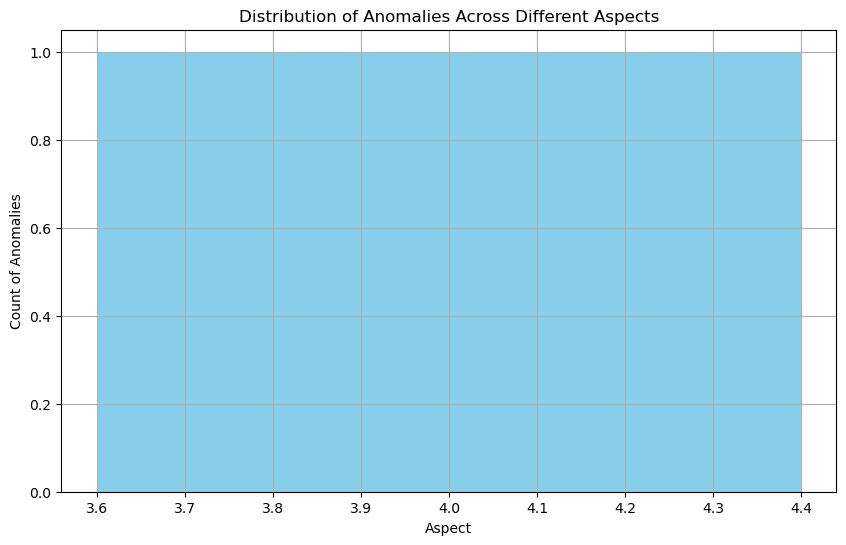

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset with anomalies
file_path = 'autoencoder_results_with_anomalies.csv'
data = pd.read_csv(file_path)

# Display the first few rows of the dataset to understand its structure
print(data.head())

# Analyze the dataset for mental health concerns
# Filter the anomalies
anomalies = data[data['Is_Anomaly'] == True]

# Display the anomalies
print("Potential mental health concerns detected:")
print(anomalies)

# Save the anomalies to a new CSV file for further analysis
anomalies.to_csv('mental_health_anomalies.csv', index=False)
print("Anomalies saved to 'mental_health_anomalies.csv'.")

# Further analysis on the anomalies
# Group by Aspect and count the number of anomalies in each aspect
aspect_anomalies = anomalies.groupby('Aspect').size().reset_index(name='Count')

# Display the count of anomalies in each aspect
print("Count of anomalies in each aspect:")
print(aspect_anomalies)

# Save the count of anomalies in each aspect to a new CSV file
aspect_anomalies.to_csv('aspect_anomalies_count.csv', index=False)
print("Aspect anomalies count saved to 'aspect_anomalies_count.csv'.")

# Plotting the distribution of anomalies across different aspects
plt.figure(figsize=(10, 6))
plt.bar(aspect_anomalies['Aspect'], aspect_anomalies['Count'], color='skyblue')
plt.xlabel('Aspect')
plt.ylabel('Count of Anomalies')
plt.title('Distribution of Anomalies Across Different Aspects')
plt.grid(True)
plt.show()

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/vedantagarwal/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/vedantagarwal/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/vedantagarwal/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/vedantagarwal/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Epoch 1/100
67/67 [==============================] - 1s 11ms/step - loss: 0.0459 - val_loss: 9.9515e-04 - lr: 0.0010
Epoch 2/100
67/67 [==============================] - 1s 10ms/step - loss: 9.9232e-04 - val_loss: 9.9515e-04 - lr: 0.0010
Epoch 3/100
67/67 [==============================] - 1s 10ms/step - loss: 9.9232e-04 - val_loss: 9.9515e-04 - lr: 0.0010
Epoch 4/100
67/67 [==============================] - 1s 10ms/step - loss: 9.9232e-04 - val_loss: 9.9515e-04 - lr: 0.0010
Epoch 5/100
67/67 [==============================] - 1s 11ms/step - loss: 9.9232e-04 - val_loss: 9.9515e-04 - lr: 0.0010
Epoch 6/100
67/67 [==============================] - 1s 10ms/step - loss: 9.9232e-04 - val_loss: 9.9515e-04 - lr: 0.0010
Epoch 7/100
67/67 [==============================] - 1s 9ms/step - loss: 9.9232e-04 - val_loss: 9.9515e-04 - lr: 5.0000e-04
Epoch 8/100
67/67 [==============================] - 1s 10ms/step - loss: 9.9232e-04 - val_loss: 9.9515e-04 - lr: 5.0000e-04
Epoch 9/100
67/67 [==========

/Users/vedantagarwal/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


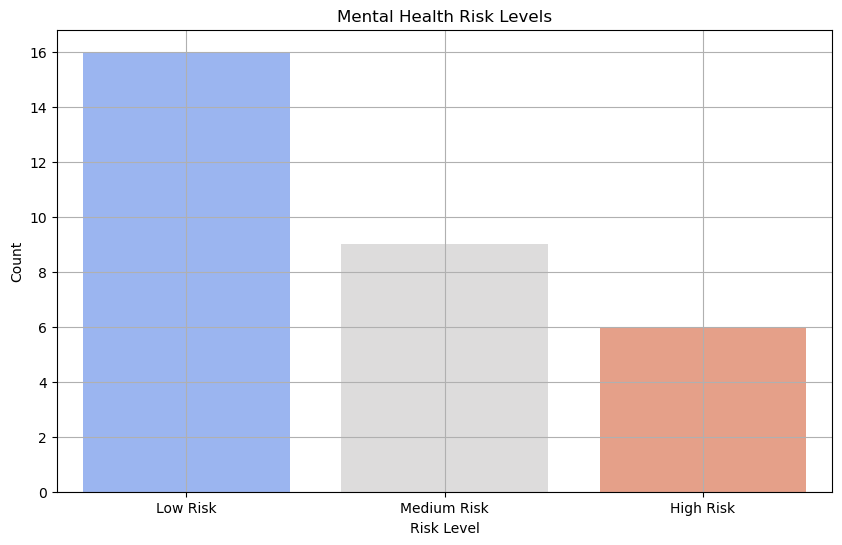

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.cluster import KMeans
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize NLP components
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
punctuation = set(string.punctuation)

def preprocess_text(text):
    text = text.lower()
    tokens = word_tokenize(text)
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and word not in punctuation]
    return ' '.join(cleaned_tokens)

# Load dataset
file1 = r"dataset_wellnessdimensions.csv"
data = pd.read_csv(file1)
data['Cleaned_Text'] = data['Text'].apply(preprocess_text)

tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X_tfidf = tfidf_vectorizer.fit_transform(data['Cleaned_Text']).toarray()

X_train, X_val = train_test_split(X_tfidf, test_size=0.2, random_state=42)

# Define the fitness function (Validation loss)
def fitness_function(params):
    learning_rate = params[0]
    num_neurons = int(params[1])
    batch_size = int(params[2])
    
    # Build the autoencoder model with the given hyperparameters
    inputs = layers.Input(shape=(X_train.shape[1],))
    encoded = layers.Dense(num_neurons, activation='relu')(inputs)
    encoded = layers.Dense(256, activation='relu')(encoded)
    attention_probs = layers.Dense(256, activation='softmax')(encoded)
    attention_output = layers.multiply([encoded, attention_probs])
    decoded = layers.Dense(num_neurons, activation='relu')(attention_output)
    decoded = layers.Dense(X_train.shape[1], activation='sigmoid')(decoded)
    
    autoencoder = models.Model(inputs, decoded)
    autoencoder.compile(optimizer='adam', loss='mean_squared_error')
    
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = autoencoder.fit(X_train, X_train, epochs=50, batch_size=batch_size, validation_data=(X_val, X_val), callbacks=[early_stopping], verbose=0)
    
    val_loss = history.history['val_loss'][-1]
    return val_loss

# SMO setup (Define the parameter ranges)
param_ranges = {
    "learning_rate": [0.0001, 0.01],
    "num_neurons": [128, 512],
    "batch_size": [16, 128]
}
num_spiders = 10
iterations = 20

# Initialize population randomly
populations = np.array([
    [
        np.random.uniform(param_ranges["learning_rate"][0], param_ranges["learning_rate"][1]),
        np.random.uniform(param_ranges["num_neurons"][0], param_ranges["num_neurons"][1]),
        np.random.uniform(param_ranges["batch_size"][0], param_ranges["batch_size"][1])
    ]
    for _ in range(num_spiders)
])

# SMO Algorithm for hyperparameter optimization
for iteration in range(iterations):
    fitness_scores = np.array([fitness_function(params) for params in populations])
    global_leader_idx = np.argmin(fitness_scores)
    global_leader = populations[global_leader_idx]
    
    for i in range(num_spiders):
        if i != global_leader_idx:
            populations[i] = populations[i] + np.random.uniform(-0.01, 0.01, size=3) * (global_leader - populations[i])
            populations[:, 0] = np.clip(populations[:, 0], param_ranges["learning_rate"][0], param_ranges["learning_rate"][1])
            populations[:, 1] = np.clip(populations[:, 1], param_ranges["num_neurons"][0], param_ranges["num_neurons"][1])
            populations[:, 2] = np.clip(populations[:, 2], param_ranges["batch_size"][0], param_ranges["batch_size"][1])

best_hyperparams = populations[global_leader_idx]

# Build the final autoencoder model with optimized hyperparameters
final_autoencoder = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(int(best_hyperparams[1] * 2), activation='relu'),
    layers.Dense(int(best_hyperparams[1]), activation='relu'),
    layers.Dense(int(best_hyperparams[1] / 2), activation='relu'),
    layers.Dense(X_train.shape[1], activation='sigmoid')
])

final_autoencoder.compile(optimizer='adam', loss='mean_squared_error')
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001)

history = final_autoencoder.fit(X_train, X_train, epochs=100, batch_size=int(best_hyperparams[2]), validation_data=(X_val, X_val), callbacks=[early_stopping, reduce_lr], verbose=1)

# Anomaly Detection
X_val_reconstructed = final_autoencoder.predict(X_val)
reconstruction_error = np.mean(np.square(X_val - X_val_reconstructed), axis=1)
threshold = np.percentile(reconstruction_error, 95)
anomalies = reconstruction_error > threshold

# Save Anomalies
anomalies_df = pd.DataFrame(data.iloc[:len(X_val)].copy())
anomalies_df['Reconstruction_Error'] = reconstruction_error
anomalies_df['Is_Anomaly'] = anomalies
anomalies_df.to_csv('autoencoder_results_with_anomalies.csv', index=False)

# Clustering Anomalies
anomalies_only = anomalies_df[anomalies_df['Is_Anomaly'] == True].copy()
kmeans = KMeans(n_clusters=3, random_state=42)
anomalies_only['Cluster'] = kmeans.fit_predict(anomalies_only[['Reconstruction_Error']])
anomalies_only.to_csv('anomalies_clustered.csv', index=False)

# Sentiment Analysis
analyzer = SentimentIntensityAnalyzer()
anomalies_only['Sentiment_Score'] = anomalies_only['Text'].apply(lambda x: analyzer.polarity_scores(x)['compound'])
anomalies_only['Sentiment_Category'] = anomalies_only['Sentiment_Score'].apply(lambda x: 'Positive' if x >= 0.05 else 'Negative' if x <= -0.05 else 'Neutral')
anomalies_only.to_csv('anomalies_with_sentiment.csv', index=False)

# Risk Categorization
def categorize_risk(row):
    if row['Cluster'] == 2 and row['Sentiment_Category'] == 'Negative':
        return 'High Risk'
    elif row['Cluster'] == 1 and row['Sentiment_Category'] == 'Negative':
        return 'Medium Risk'
    else:
        return 'Low Risk'

anomalies_only['Risk_Category'] = anomalies_only.apply(categorize_risk, axis=1)
anomalies_only.to_csv('mental_health_risk_assessment.csv', index=False)

# Visualization
plt.figure(figsize=(10, 6))
sns.countplot(x=anomalies_only['Risk_Category'], palette='coolwarm')
plt.title('Mental Health Risk Levels')
plt.xlabel('Risk Level')
plt.ylabel('Count')
plt.grid(True)
plt.show()

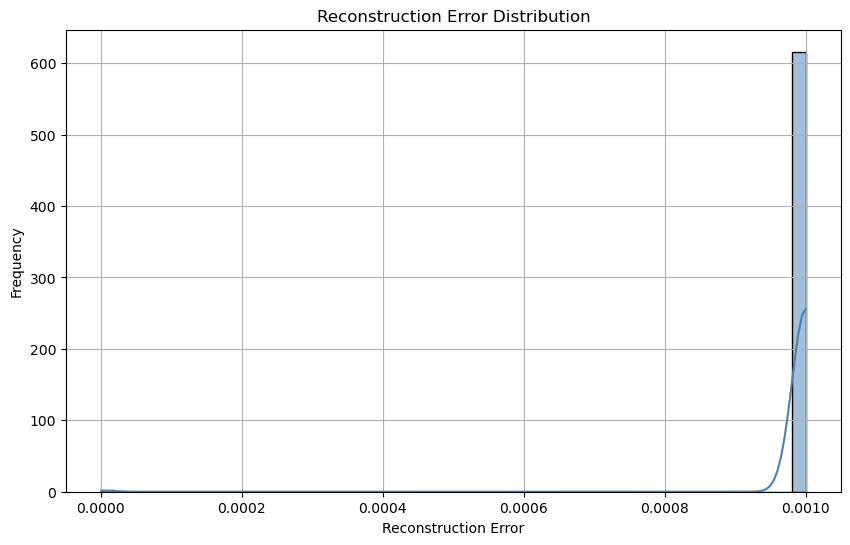

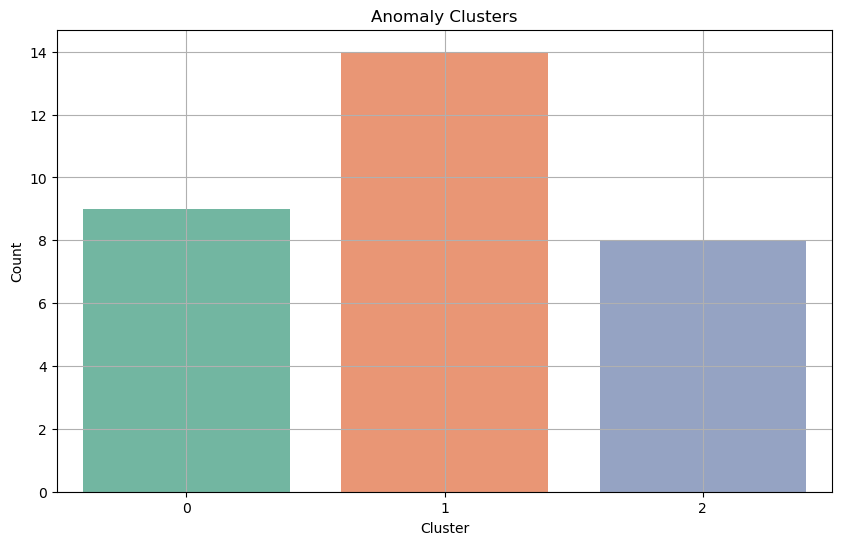

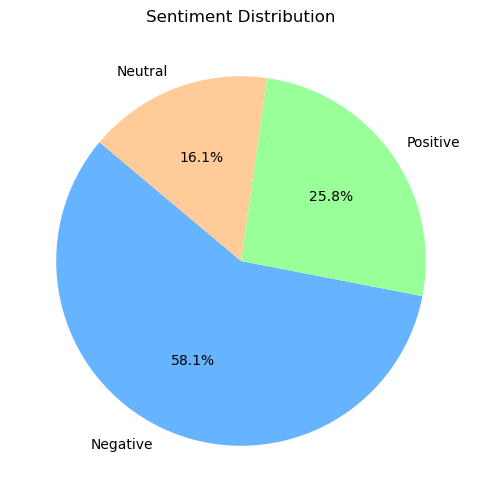

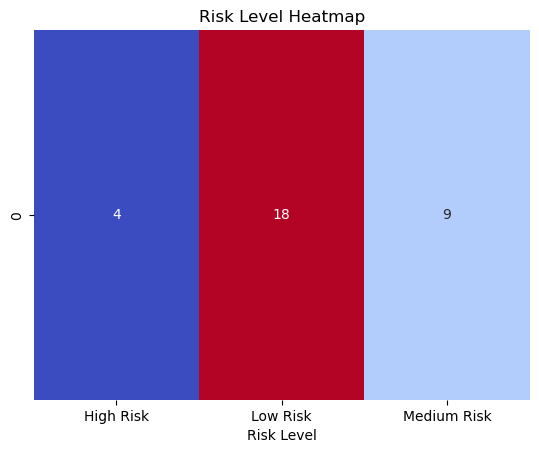

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV files
autoencoder_results = pd.read_csv('autoencoder_results_with_anomalies_2.csv')
anomalies_clustered = pd.read_csv('anomalies_clustered_2.csv')
anomalies_with_sentiment = pd.read_csv('anomalies_with_sentiment_2.csv')
risk_assessment = pd.read_csv('mental_health_risk_assessment_2.csv')

# Visualization 1: Reconstruction Error Distribution
plt.figure(figsize=(10, 6))
sns.histplot(autoencoder_results['Reconstruction_Error'], kde=True, bins=50, color='steelblue')
plt.title('Reconstruction Error Distribution')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Visualization 2: Anomaly Clusters
plt.figure(figsize=(10, 6))
sns.countplot(x='Cluster', data=anomalies_clustered, palette='Set2')
plt.title('Anomaly Clusters')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.grid(True)
plt.show()

# Visualization 3: Sentiment Distribution
plt.figure(figsize=(8, 6))
sentiment_counts = anomalies_with_sentiment['Sentiment_Category'].value_counts()
sentiment_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=['#66b3ff', '#99ff99', '#ffcc99'])
plt.title('Sentiment Distribution')
plt.ylabel('')
plt.show()

# Visualization 4: Risk Levels (Already present, adding heatmap for deeper view)
risk_counts = risk_assessment['Risk_Category'].value_counts().sort_index()
sns.heatmap(risk_counts.values.reshape(1, -1), annot=True, cmap='coolwarm', cbar=False, xticklabels=risk_counts.index)
plt.title('Risk Level Heatmap')
plt.xlabel('Risk Level')
plt.show()
